# Week 7 - Machine Learning Basics

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from google.colab import files

uploaded = files.upload()

os.makedirs("models", exist_ok=True)
os.makedirs("graphs", exist_ok=True)

print("Current Folder:", os.getcwd())
print("Files:", os.listdir())


Saving Clean_Bright.csv to Clean_Bright.csv
Saving Clean_Dark.csv to Clean_Dark.csv
Saving Clean_Dim.csv to Clean_Dim.csv
Current Folder: /content
Files: ['.config', 'Clean_Dark.csv', 'models', 'graphs', 'Clean_Bright.csv', 'Clean_Dim.csv', 'sample_data']


In [4]:
def load_dataset(clean_name, raw_name, label):
    if os.path.exists(clean_name):
        df = pd.read_csv(clean_name)
    elif os.path.exists(raw_name):
        df = pd.read_csv(raw_name, header=None, names=["Lux"])
        df["Reading"] = range(1, len(df)+1)
        df = df.dropna().drop_duplicates()
        df["Smoothed Lux"] = df["Lux"].rolling(window=5, min_periods=1).mean()
        df.to_csv(clean_name, index=False)
    else:
        raise FileNotFoundError(f"Neither {clean_name} nor {raw_name} was found.")
    df["Label"] = label
    return df

bright = load_dataset("Clean_Bright.csv","Bright.csv","Bright")
dim = load_dataset("Clean_Dim.csv","Dim.csv","Dim")
dark = load_dataset("Clean_Dark.csv","Dark.csv","Dark")

df = pd.concat([bright, dim, dark], ignore_index=True)
print(df.head())
print(df.shape)


   Reading     Lux  Anomaly  Smoothed Lux   Label
0        1  415.83    False        415.83  Bright
1        2  415.83    False        415.83  Bright
2        3  415.83    False        415.83  Bright
3        4  415.83    False        415.83  Bright
4        5  415.83    False        415.83  Bright
(111297, 5)


In [5]:
features=["Lux"]
if "Smoothed Lux" in df.columns:
    features.append("Smoothed Lux")

X=df[features]
y=df["Label"]

encoder=LabelEncoder()
y=encoder.fit_transform(y)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)


In [6]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
pred_knn=knn.predict(X_test)
knn_acc=accuracy_score(y_test,pred_knn)
print("KNN Accuracy:",knn_acc)
print(classification_report(y_test,pred_knn,target_names=encoder.classes_))
joblib.dump(knn,"models/knn_model.pkl")


KNN Accuracy: 0.976145552560647
              precision    recall  f1-score   support

      Bright       0.99      0.99      0.99      7359
        Dark       0.97      0.98      0.97      7590
         Dim       0.97      0.97      0.97      7311

    accuracy                           0.98     22260
   macro avg       0.98      0.98      0.98     22260
weighted avg       0.98      0.98      0.98     22260



['models/knn_model.pkl']

In [7]:
tree=DecisionTreeClassifier(random_state=42)
tree.fit(X_train,y_train)
pred_tree=tree.predict(X_test)
tree_acc=accuracy_score(y_test,pred_tree)
print("Decision Tree Accuracy:",tree_acc)
print(classification_report(y_test,pred_tree,target_names=encoder.classes_))
joblib.dump(tree,"models/decision_tree_model.pkl")


Decision Tree Accuracy: 0.9781221922731357
              precision    recall  f1-score   support

      Bright       0.99      0.99      0.99      7359
        Dark       0.98      0.96      0.97      7590
         Dim       0.96      0.99      0.97      7311

    accuracy                           0.98     22260
   macro avg       0.98      0.98      0.98     22260
weighted avg       0.98      0.98      0.98     22260



['models/decision_tree_model.pkl']

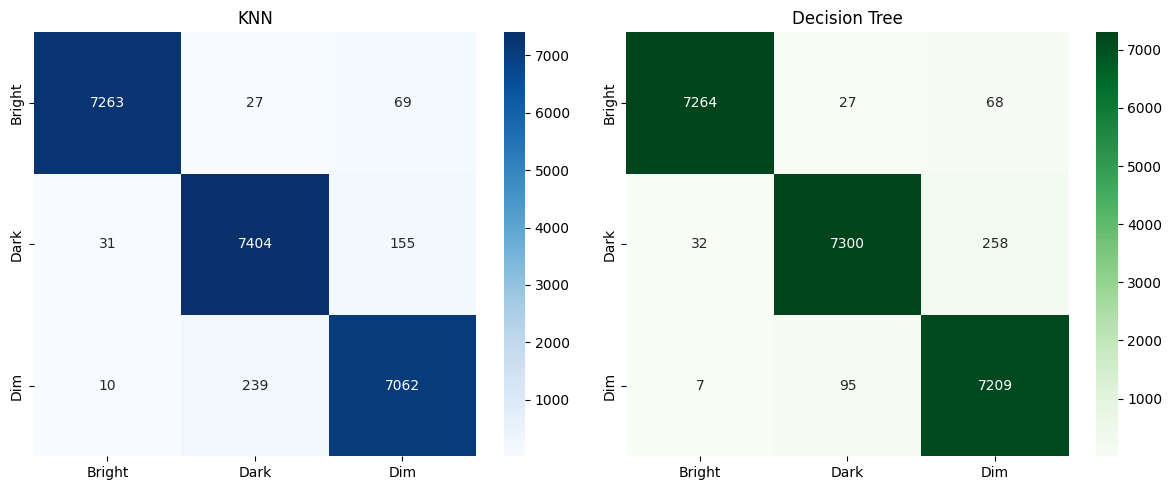

In [8]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(confusion_matrix(y_test,pred_knn),annot=True,fmt="d",cmap="Blues",
xticklabels=encoder.classes_,yticklabels=encoder.classes_,ax=ax[0])
ax[0].set_title("KNN")
sns.heatmap(confusion_matrix(y_test,pred_tree),annot=True,fmt="d",cmap="Greens",
xticklabels=encoder.classes_,yticklabels=encoder.classes_,ax=ax[1])
ax[1].set_title("Decision Tree")
plt.tight_layout()
plt.savefig("graphs/confusion_matrix.png")
plt.show()


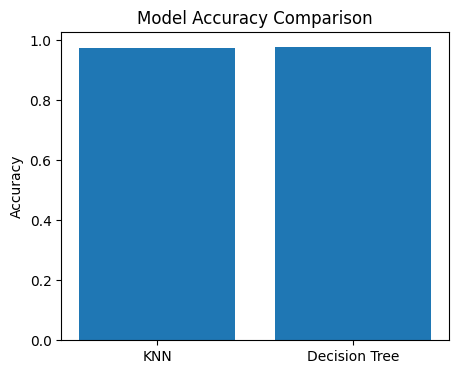

In [9]:
plt.figure(figsize=(5,4))
plt.bar(["KNN","Decision Tree"],[knn_acc,tree_acc])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.savefig("graphs/model_accuracy.png")
plt.show()


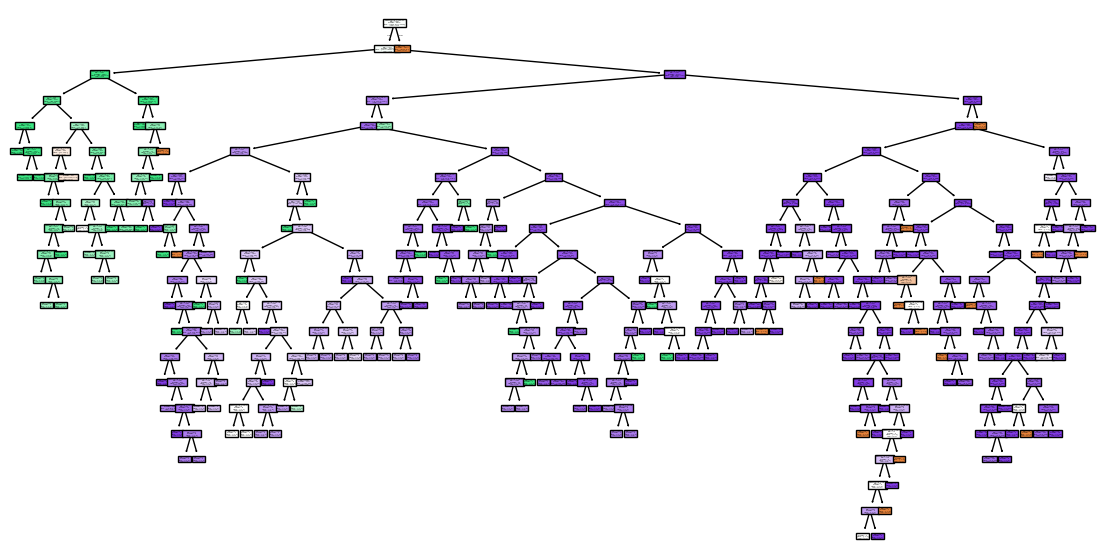

In [10]:
plt.figure(figsize=(14,7))
plot_tree(tree,feature_names=features,class_names=encoder.classes_,filled=True)
plt.savefig("graphs/decision_tree.png")
plt.show()


In [11]:
df.to_csv("Combined_Dataset.csv",index=False)
print("All tasks completed successfully!")
print("Generated:")
print("- Combined_Dataset.csv")
print("- models/")
print("- graphs/")


All tasks completed successfully!
Generated:
- Combined_Dataset.csv
- models/
- graphs/
